In [2]:
import pandas as pd

In [2]:
df=pd.read_csv('fruit.csv')
df

,Weight,Texture,Color,Fruit
0,150,smooth,red,apple
1,170,rough,orange,orange
2,140,smooth,green,apple
3,180,rough,orange,orange
4,160,smooth,red,apple
5,155,rough,yellow,orange


In [3]:
import numpy as np
df['Color']=np.where(df['Color']=='red',0,
            np.where(df['Color']=='orange',1,
            np.where(df['Color']=='green',2,3)))
df['Fruit']=np.where(df['Fruit']=='apple',0,1)
df['Texture']=np.where(df['Texture']=='smooth',0,1)
df

,Weight,Texture,Color,Fruit
0,150,0,0,0
1,170,1,1,1
2,140,0,2,0
3,180,1,1,1
4,160,0,0,0
5,155,1,3,1


In [4]:
x=df[['Weight','Texture','Color']]
y=df['Fruit']
print(x.shape)
print(y.shape)

(6, 3)
(6,)


In [5]:
from sklearn.ensemble import RandomForestClassifier
rf_classifier=RandomForestClassifier(criterion='entropy',n_estimators=100,random_state=30)

rf_classifier.fit(x,y)
pred=rf_classifier.predict(x)
print(pred)

[0 1 0 1 0 1]


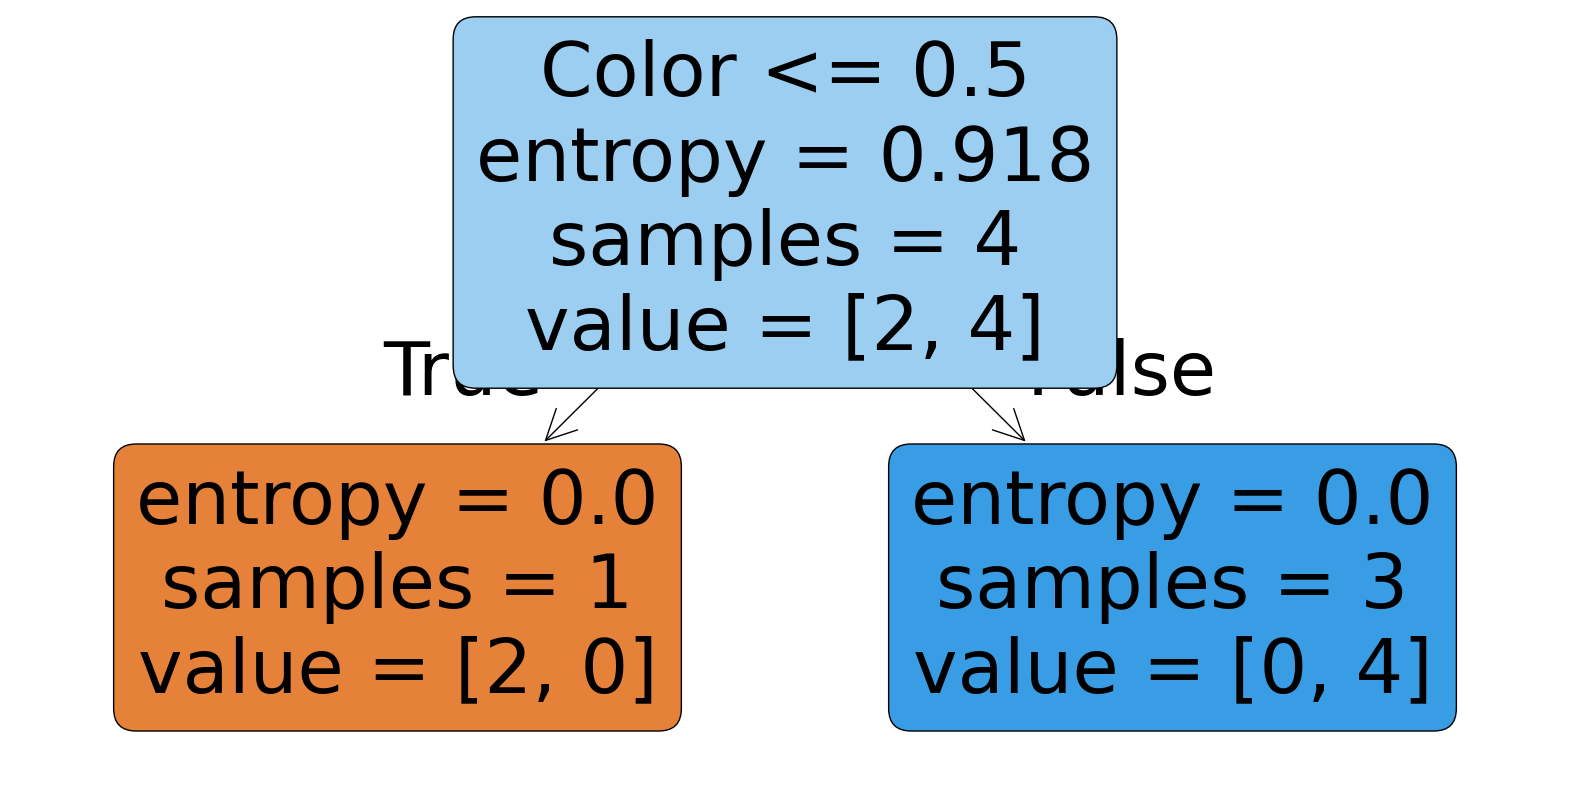

In [6]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
choose_tree=rf_classifier.estimators_[0]
plot_tree(choose_tree,feature_names=x.columns,filled=True,rounded=True)
plt.show()


In [7]:
from sklearn.metrics import accuracy_score,precision_score,recall_score,confusion_matrix

cm=confusion_matrix(y,pred)
print("confusion_matrix = ",cm)

confusion_matrix =  [[3 0]
 [0 3]]


In [8]:
print("Accuracy = ",accuracy_score(y,pred))

Accuracy =  1.0


In [9]:
print("Recall score  = ",recall_score(y,pred))

Recall score  =  1.0


In [11]:
print("Precision score = ",precision_score(y,pred))

Precision score =  1.0


# Support Vector Machine :

In [3]:
df=pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
x=df.iloc[:,0:8]
y=df['Outcome']
print(x.shape)
print(y.shape)

(768, 8)
(768,)


In [5]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=1)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(614, 8)
(154, 8)
(614,)
(154,)


In [9]:
from sklearn.svm import SVC
classifier = SVC(kernel='rbf',C=5.0,random_state=1)
model=classifier.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(y_pred)

[0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 1 0 0 0 0 1 0 0 0 0 0 1 0 1 0
 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 1 0 0 0 1 0 0 0 1 0 1 0 0 0 0 0 1 1 1 1 0 0
 1 0 1 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 1 0 0 0 0 0 0 0 1
 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 0 1 0 1 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 0 0 0 1 0 0]


In [10]:
from sklearn.metrics import accuracy_score,confusion_matrix

print("confusion_matrix = ",confusion_matrix(y_test,y_pred))

print("Accuracy = ",accuracy_score(y_test,y_pred))

confusion_matrix =  [[94  5]
 [26 29]]
Accuracy =  0.7987012987012987
